In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, median_absolute_error
from sklearn.model_selection import GridSearchCV


In [54]:
ev1 = pd.read_csv('../../Datasets/amazon_final.csv')
ev1.head(1)

,product_title,product_rating,total_reviews,purchased_last_month,original_price,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,...,badge_amazons,badge_best_seller,badge_ends_in,badge_limited_time_deal,badge_no_badge,badge_save_xpct,product_category,log_purchased_last_month,log_original_price,log_total_reviews
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,358.0,0,239.99,1,No Coupon,1,0,https://m.media-amazon.com/images/I/51vvx1JymA...,...,0,0,0,0,1,0,PC Components,0.0,5.484755,5.883322


- DROP purchased_last_month
- DROP total_reviews
- DROP original_price
- DROP coupon
- DROP title
- DROP product_img

In [55]:
ev1.drop(columns=['product_title', 'total_reviews', 'purchased_last_month', 'coupon', 'product_image_url'], inplace=True)

## Division en train/test

In [56]:
#Usamos el dataframe que ya tiene las limpiezas básicas (sin duplicados, sin precios 0)
train_df, test_df = train_test_split(ev1, test_size=0.20, random_state=42)

# 2. FUNCIÓN PARA CALCULAR LÍMITES (Basada solo en Train)
def obtener_umbrales_iqr(df):
    umbrales = {}
    for cat in df['product_category'].unique():
        precios = df[df['product_category'] == cat]['original_price']
        q1 = precios.quantile(0.25)
        q3 = precios.quantile(0.75)
        iqr = q3 - q1
        limite_premium = q3 + (1.5 * iqr)
        umbrales[cat] = {'q1': q1, 'limite_premium': limite_premium}
    return umbrales

# Calculamos los límites usando SOLO el set de entrenamiento
dict_umbrales = obtener_umbrales_iqr(train_df)

# 3. FUNCIÓN PARA APLICAR LAS GAMAS (Usando los límites calculados)
def asignar_segmento(row, umbrales_dict):
    cat = row['product_category']
    precio = row['original_price']
    
    # Si la categoría no estaba en train (raro pero posible), usamos valores por defecto
    if cat not in umbrales_dict:
        return 'Media'
    
    if precio <= umbrales_dict[cat]['q1']:
        return 'Baja'
    elif precio > umbrales_dict[cat]['limite_premium']:
        return 'Alta'
    else:
        return 'Media'

# Aplicamos la segmentación a ambos conjuntos
train_df['product_segment'] = train_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))
test_df['product_segment'] = test_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))

# 4. ONE-HOT ENCODING (Asegurando que las columnas coincidan)
train_dummies = pd.get_dummies(train_df['product_segment'], prefix='segment', dtype=int)
test_dummies = pd.get_dummies(test_df['product_segment'], prefix='segment', dtype=int)

# Concatenamos y eliminamos columnas sobrantes
X_train = pd.concat([train_df.drop(columns=['product_segment', 'original_price', 'log_original_price', 'product_category']), train_dummies], axis=1)
X_test = pd.concat([test_df.drop(columns=['product_segment', 'original_price', 'log_original_price', 'product_category']), test_dummies], axis=1)

y_train = train_df['log_original_price']
y_test = test_df['log_original_price']

In [57]:
ev1.drop(columns=['original_price'], inplace=True)

In [58]:
# Aplicar One-Hot Encoding a las categorías
ev1 = pd.get_dummies(ev1, columns=['product_category'], prefix='cat')

In [59]:
ev1.head()

,product_rating,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,badge_amazons,badge_best_seller,badge_ends_in,badge_limited_time_deal,...,cat_PC Components,cat_Power & Batteries,cat_Printers & Scanners (Hardware),cat_Small Gadget Accessories (Cases & Protectors),cat_Smart Home & Security,cat_Storage & Memory Cards,cat_TV & Video Displays,cat_Tablets & E-readers (DEVICES ONLY),cat_Video Game Consoles & Virtual Reality,cat_Wearables
0,4.4,1,1,0,0,0.0,0,0,0,0,...,True,False,False,False,False,False,False,False,False,False
1,4.6,1,1,0,0,0.0,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
2,4.6,0,0,1,0,0.0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
3,4.6,0,0,0,0,0.0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
4,4.5,0,0,0,0,0.0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False


In [60]:
ev1.to_csv('../../Datasets/evaluacion1.csv', index=False)

## Codigo de entrenamiento

### 1 Versión

In [61]:
# --- 5. ENTRENAMIENTO ---
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='r2')
modelo_rf.fit(X_train, y_train)

# --- 6. EVALUACIÓN ---
y_pred_log = modelo_rf.predict(X_test)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred_log)

# Calculamos métricas globales en Euros
mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100

# --- 7. ANÁLISIS POR SEGMENTO ---
# Creamos un dataframe temporal para segmentar el error
df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})

# Calculamos el error porcentual para cada fila
df_residuos['Error_Relativo_%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

# Ahora sacamos la media por segmento
for col in [c for c in X_test.columns if 'segment_' in c]:
    mask = X_test[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'Error_Relativo_%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)

# --- IMPRESIÓN DE RESULTADOS FINAL ---

print("\n" + "="*40)
print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print("="*40)
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print("-" * 40)
print(f"R2 Score (Calidad):      {r2_score(y_test, y_pred_log):.4f}")
print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)

Segmento segment_Alta:
   - Error en Euros (MAE): 593.98 €
   - Error en % (MAPE):    89.13 %
--------------------
Segmento segment_Baja:
   - Error en Euros (MAE): 15.04 €
   - Error en % (MAPE):    57.77 %
--------------------
Segmento segment_Media:
   - Error en Euros (MAE): 118.58 €
   - Error en % (MAPE):    86.13 %
--------------------

📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      136.36 €
MedAE (Error Típico):   44.75 €
RMSE (Error Penalizado): 320.51 €
MAPE (Error Porcentual): 79.14 %
----------------------------------------
R2 Score (Calidad):      0.6395
R2 CV (Estabilidad):     0.6264 (+/- 0.0091)


Que el RMSE (320 €) sea casi el triple que el MAE (136 €) confirma matemáticamente que tienes unos pocos productos caros con errores gigantes que están "ensuciando" la estadística.

(MAPE 79%): Este porcentaje es alto porque, probablemente, en productos muy baratos (ej. 5 €), fallar por 15 € supone un error porcentual enorme, aunque en dinero sea poco.

C:\Users\diego\AppData\Local\Temp\ipykernel_22208\1223987818.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importancia_rf, palette='magma')


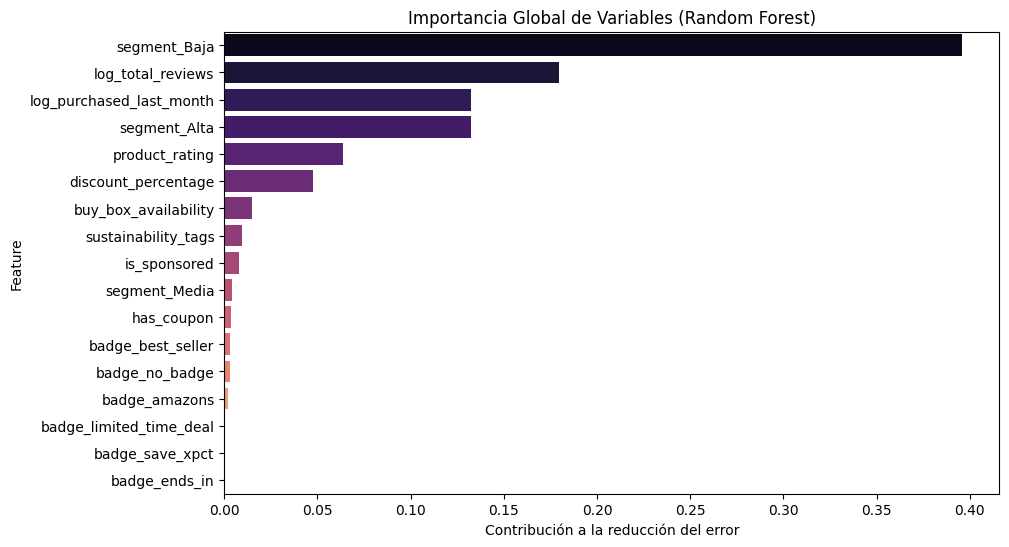

In [62]:
# Extraer importancias y nombres de columnas
importancias_rf = modelo_rf.feature_importances_
features = X_train.columns

# Crear un DataFrame para facilitar el manejo
df_importancia_rf = pd.DataFrame({'Feature': features, 'Importance': importancias_rf})
df_importancia_rf = df_importancia_rf.sort_values(by='Importance', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importancia_rf, palette='magma')
plt.title('Importancia Global de Variables (Random Forest)')
plt.xlabel('Contribución a la reducción del error')
plt.show()

## Ajuste de hiperparámetros

In [63]:
# Definimos la rejilla de parámetros
param_grid = {
    'n_estimators': [100, 300], 
    'max_depth': [20, 30, None], 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None] # None usa todas las variables
}

# Configuramos el modelo base
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,            
    scoring='r2',    # Queremos maximizar la explicación del precio
    n_jobs=-1,       
    verbose=2        
)

# ¡A buscar!
grid_search.fit(X_train, y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_search.best_params_}")
print(f"Mejor R2 en entrenamiento: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejor combinación: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Mejor R2 en entrenamiento: 0.6665


### Nuevo modelo con estos hiperparámetros

In [66]:
# --- 5. ENTRENAMIENTO ---
modelo_rf = RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1)
cv_scores = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='r2')
modelo_rf.fit(X_train, y_train)

# --- 6. EVALUACIÓN ---
y_pred_log = modelo_rf.predict(X_test)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred_log)

# Calculamos métricas globales en Euros
mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100

# --- 7. ANÁLISIS POR SEGMENTO ---
# Creamos un dataframe temporal para segmentar el error
df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})

# Calculamos el error porcentual para cada fila
df_residuos['Error_Relativo_%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

# Ahora sacamos la media por segmento
for col in [c for c in X_test.columns if 'segment_' in c]:
    mask = X_test[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'Error_Relativo_%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)

# --- IMPRESIÓN DE RESULTADOS FINAL ---

print("\n" + "="*40)
print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print("="*40)
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print("-" * 40)
print(f"R2 Score (Calidad):      {r2_score(y_test, y_pred_log):.4f}")
print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)

Segmento segment_Alta:
   - Error en Euros (MAE): 574.73 €
   - Error en % (MAPE):    80.41 %
--------------------
Segmento segment_Baja:
   - Error en Euros (MAE): 14.54 €
   - Error en % (MAPE):    54.39 %
--------------------
Segmento segment_Media:
   - Error en Euros (MAE): 113.72 €
   - Error en % (MAPE):    78.32 %
--------------------

📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      131.28 €
MedAE (Error Típico):   44.07 €
RMSE (Error Penalizado): 322.85 €
MAPE (Error Porcentual): 72.37 %
----------------------------------------
R2 Score (Calidad):      0.6707
R2 CV (Estabilidad):     0.6665 (+/- 0.0064)


C:\Users\diego\AppData\Local\Temp\ipykernel_22208\1223987818.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importancia_rf, palette='magma')


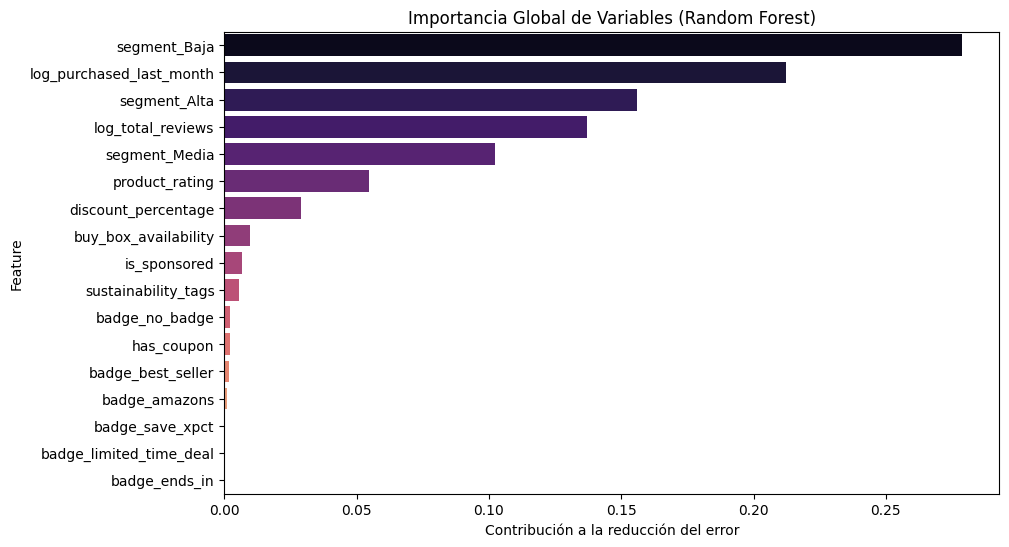

In [65]:
# Extraer importancias y nombres de columnas
importancias_rf = modelo_rf.feature_importances_
features = X_train.columns

# Crear un DataFrame para facilitar el manejo
df_importancia_rf = pd.DataFrame({'Feature': features, 'Importance': importancias_rf})
df_importancia_rf = df_importancia_rf.sort_values(by='Importance', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importancia_rf, palette='magma')
plt.title('Importancia Global de Variables (Random Forest)')
plt.xlabel('Contribución a la reducción del error')
plt.show()

### Sugerencias
- Limpia Outliers: Borra el 1% de los productos más caros y el 1% de los más baratos. A veces, 10 productos "locos" arruinan el aprendizaje de 7.000.

- Quitar categoria Other electronics? Hay de todo por lo que no lo hara muy bien (hay 121 productos ahi)

- Sobre Badges:
    - Falta de correlación con el Precio: Un producto de 10€ puede ser "Best Seller" y uno de 1.000€ también. El badge no ayuda a distinguir el precio, sino el éxito de ventas (que ya tienes capturado en log_purchased_last_month).
    - Es muy probable que badge_limited_time_deal o badge_save_xpct solo aparezcan en un 1% o 2% de tus 7.718 productos. Para el modelo, es más seguro ignorarlos que intentar crear una regla basada en 10 ejemplos.
    - Si un producto tiene badge_best_seller, lo más probable es que ya tenga un log_purchased_last_month altísimo. El modelo prefiere usar la variable numérica (ventas) porque es mucho más rica en información que un simple "Sí/No".
    - Podriamos probar a crear total_badges: Una columna numérica que sume cuántos badges tiene el producto (0, 1, 2, 3...).

**Nuevas características**

- **La Marca:**  La primera palabra del título (suele ser la marca) o buscar coincidencias con una lista de marcas conocidas.

- **Especificaciones Técnicas:** Extraer Capacidad (GB), Potencia (W) y Tamaño (pulgadas). Estas variables permitirán al modelo entender que un disco duro de 2TB debe costar más que uno de 500GB, aunque estén en la misma categoría. Codigo en Gemini (Extractor Especializado por Categoría)

### Modelo con una reclasificacion de categorias:

In [68]:
df_auditado = pd.read_csv('../../Datasets/auditoria1.csv')

In [69]:
df_auditado.drop(columns=['product_title', 'total_reviews', 'purchased_last_month', 'coupon', 'product_image_url'], inplace=True)

In [70]:
#Usamos el dataframe que ya tiene las limpiezas básicas (sin duplicados, sin precios 0)
train_df, test_df = train_test_split(df_auditado, test_size=0.20, random_state=42)

# 2. FUNCIÓN PARA CALCULAR LÍMITES (Basada solo en Train)
def obtener_umbrales_iqr(df):
    umbrales = {}
    for cat in df['product_category'].unique():
        precios = df[df['product_category'] == cat]['original_price']
        q1 = precios.quantile(0.25)
        q3 = precios.quantile(0.75)
        iqr = q3 - q1
        limite_premium = q3 + (1.5 * iqr)
        umbrales[cat] = {'q1': q1, 'limite_premium': limite_premium}
    return umbrales

# Calculamos los límites usando SOLO el set de entrenamiento
dict_umbrales = obtener_umbrales_iqr(train_df)

# 3. FUNCIÓN PARA APLICAR LAS GAMAS (Usando los límites calculados)
def asignar_segmento(row, umbrales_dict):
    cat = row['product_category']
    precio = row['original_price']
    
    # Si la categoría no estaba en train (raro pero posible), usamos valores por defecto
    if cat not in umbrales_dict:
        return 'Media'
    
    if precio <= umbrales_dict[cat]['q1']:
        return 'Baja'
    elif precio > umbrales_dict[cat]['limite_premium']:
        return 'Alta'
    else:
        return 'Media'

# Aplicamos la segmentación a ambos conjuntos
train_df['product_segment'] = train_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))
test_df['product_segment'] = test_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))

# 4. ONE-HOT ENCODING (Asegurando que las columnas coincidan)
train_dummies = pd.get_dummies(train_df['product_segment'], prefix='segment', dtype=int)
test_dummies = pd.get_dummies(test_df['product_segment'], prefix='segment', dtype=int)

# Concatenamos y eliminamos columnas sobrantes
X_train = pd.concat([train_df.drop(columns=['product_segment', 'original_price', 'log_original_price', 'product_category']), train_dummies], axis=1)
X_test = pd.concat([test_df.drop(columns=['product_segment', 'original_price', 'log_original_price', 'product_category']), test_dummies], axis=1)

y_train = train_df['log_original_price']
y_test = test_df['log_original_price']

In [71]:
df_auditado.drop(columns=['original_price'], inplace=True)

# Aplicar One-Hot Encoding a las categorías
df_auditado = pd.get_dummies(df_auditado, columns=['product_category'], prefix='cat')

In [72]:
# Definimos la rejilla de parámetros
param_grid = {
    'n_estimators': [100, 300], 
    'max_depth': [20, 30, None], 
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', None] # None usa todas las variables
}

# Configuramos el modelo base
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,            
    scoring='r2',    # Queremos maximizar la explicación del precio
    n_jobs=-1,       
    verbose=2        
)

# ¡A buscar!
grid_search.fit(X_train, y_train)

# Mejores resultados
print(f"Mejor combinación: {grid_search.best_params_}")
print(f"Mejor R2 en entrenamiento: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejor combinación: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Mejor R2 en entrenamiento: 0.6232


In [73]:
# --- 5. ENTRENAMIENTO ---
modelo_rf = RandomForestRegressor(n_estimators=300, max_depth=30, min_samples_split=10, min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1)
cv_scores = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='r2')
modelo_rf.fit(X_train, y_train)

# --- 6. EVALUACIÓN ---
y_pred_log = modelo_rf.predict(X_test)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(y_pred_log)

# Calculamos métricas globales en Euros
mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100

# --- 7. ANÁLISIS POR SEGMENTO ---
# Creamos un dataframe temporal para segmentar el error
df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})

# Calculamos el error porcentual para cada fila
df_residuos['Error_Relativo_%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

# Ahora sacamos la media por segmento
for col in [c for c in X_test.columns if 'segment_' in c]:
    mask = X_test[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'Error_Relativo_%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)

# --- IMPRESIÓN DE RESULTADOS FINAL ---

print("\n" + "="*40)
print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print("="*40)
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print("-" * 40)
print(f"R2 Score (Calidad):      {r2_score(y_test, y_pred_log):.4f}")
print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)

Segmento segment_Alta:
   - Error en Euros (MAE): 551.06 €
   - Error en % (MAPE):    89.54 %
--------------------
Segmento segment_Baja:
   - Error en Euros (MAE): 17.75 €
   - Error en % (MAPE):    59.17 %
--------------------
Segmento segment_Media:
   - Error en Euros (MAE): 123.83 €
   - Error en % (MAPE):    89.57 %
--------------------

📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      135.70 €
MedAE (Error Típico):   46.05 €
RMSE (Error Penalizado): 333.01 €
MAPE (Error Porcentual): 81.95 %
----------------------------------------
R2 Score (Calidad):      0.6180
R2 CV (Estabilidad):     0.6232 (+/- 0.0117)


Probablemente porque el modelo estaba "haciendo trampas" con el ruido. Al tener productos de 5€ mezclados con los de 1.000€, el Random Forest se volvía muy conservador y predecía valores cercanos a la media para evitar errores gigantes, lo que inflaba artificialmente el $R^2$. Al separar las categorías, lo obligas a ser preciso con los portátiles de verdad, y ahí es donde se nota que le falta información técnica para distinguir un PC bueno de uno básico.

C:\Users\diego\AppData\Local\Temp\ipykernel_22208\1223987818.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importancia_rf, palette='magma')


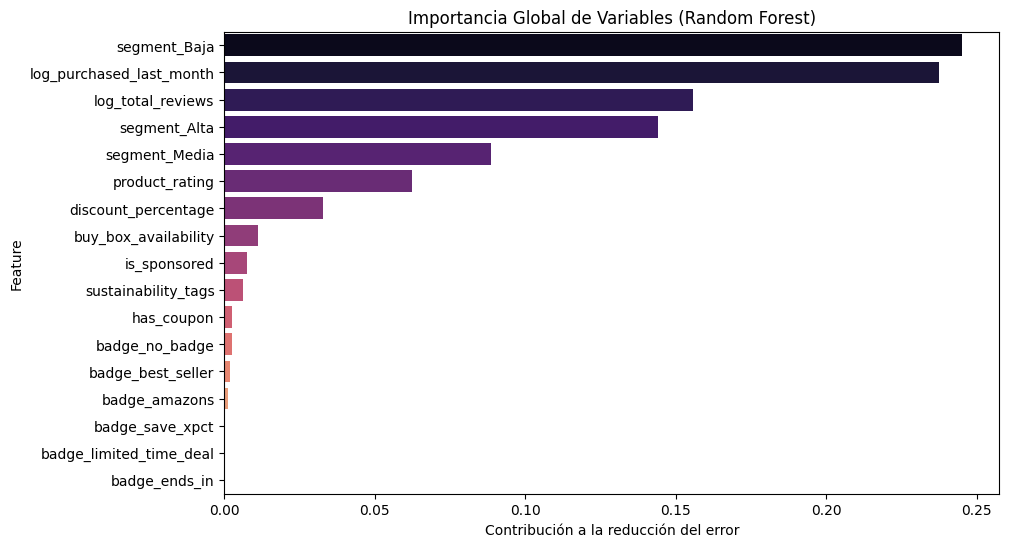

In [74]:
# Extraer importancias y nombres de columnas
importancias_rf = modelo_rf.feature_importances_
features = X_train.columns

# Crear un DataFrame para facilitar el manejo
df_importancia_rf = pd.DataFrame({'Feature': features, 'Importance': importancias_rf})
df_importancia_rf = df_importancia_rf.sort_values(by='Importance', ascending=False)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importancia_rf, palette='magma')
plt.title('Importancia Global de Variables (Random Forest)')
plt.xlabel('Contribución a la reducción del error')
plt.show()